# Importing the data and selecting subset
The data is first imported from the SQLite file and converted into a pandas dataframe. After that, all N/A and duplicate records are dropped, and a the dataset is subsetted randomly. 

In [5]:
import sqlite3
import pandas as pd
import numpy as np

conn = sqlite3.connect("./data/properties_cleaned.db")
df = pd.read_sql_query(f"SELECT * FROM properties", conn)
conn.close()

#['bedrooms', 'building_form', 'city', 'commercial_space',
# 'days_on_market', 'energy_efficient', 'energy_label', 'fixer_upper',
# 'has_balcony', 'has_garden', 'has_heat_pump', 'has_roof_terrace',
# 'has_solar_panels', 'latitude', 'living_area', 'longitude',
# 'national_monument', 'object_type', 'plot_area_m2', 'postcode4',
# 'price', 'province', 'publication_date', 'rooms', 'url', 'year_built',
# 'has_basement', 'has_attic', 'stories'],

df = df.dropna()
df = df.drop_duplicates()
#df = df.sample(n=10000, random_state=1)

# Select subset
df = df[['price', 'bedrooms', 'building_form', 
         #'city', 
         'commercial_space',
         'days_on_market', 
         'energy_efficient', 'energy_label', 'fixer_upper',
         'has_balcony', 'has_garden', 'has_heat_pump', 'has_roof_terrace',
         'has_solar_panels', 'latitude', 'living_area', 'longitude',
         'national_monument', 
         'object_type', 'plot_area_m2', #'postcode4',
         'province', 
         #'publication_date',
         #'urbanization_level',
         'addresses_per_km2', 
         'rooms', 'year_built',
         'has_basement', 'has_attic', 'stories']]

# Preprocessing and analyzing the data prior to modeling
Before the model can be created, the data has to be preprocessed and analyzed for things such as multicollinearity.

## Converting datatypes
All columns have to be converted to the proper datatypes to allow modeling

In [6]:
# CATEGORY
df['building_form'] = df['building_form'].astype('category')
df['object_type'] = df['object_type'].astype('category')
df['province'] = df['province'].astype('category')

# Ordinal category for energy_label
df['energy_label'] = pd.Categorical(
    df['energy_label'],
    categories=['g', 'f', 'e', 'd', 'c', 'b', 'a'],
    ordered=True
)

# BOOL
df['has_balcony'] = df['has_balcony'].astype(bool)
df['has_garden'] = df['has_garden'].astype(bool)
df['has_heat_pump'] = df['has_heat_pump'].astype(bool)
df['has_roof_terrace'] = df['has_roof_terrace'].astype(bool)
df['has_solar_panels'] = df['has_solar_panels'].astype(bool)
df['has_basement'] = df['has_basement'].astype(bool)
df['has_attic'] = df['has_attic'].astype(bool)
df['fixer_upper'] = df['fixer_upper'].astype(bool)
df['energy_efficient'] = df['energy_efficient'].astype(bool)
df['commercial_space'] = df['commercial_space'].astype(bool)
df['national_monument'] = df['national_monument'].astype(bool)

# INT
df['rooms'] = df['rooms'].astype(int)
df['year_built'] = df['year_built'].astype(int)
df['living_area'] = df['living_area'].astype(int)
df['plot_area_m2'] = df['plot_area_m2'].astype(int)
df['days_on_market'] = df['days_on_market'].astype(int)
df['bedrooms'] = df['bedrooms'].astype(int)
df['stories'] = df['stories'].astype(int)
df['addresses_per_km2'] = df['addresses_per_km2'].astype(int)

# FLOAT
df['latitude'] = df['latitude'].astype(float)
df['longitude'] = df['longitude'].astype(float)
df['price'] = df['price'].str.replace('€', '').str.replace('.', '').astype(float)

# print data types
print(df.dtypes)

price                 float64
bedrooms                int64
building_form        category
commercial_space         bool
days_on_market          int64
energy_efficient         bool
energy_label         category
fixer_upper              bool
has_balcony              bool
has_garden               bool
has_heat_pump            bool
has_roof_terrace         bool
has_solar_panels         bool
latitude              float64
living_area             int64
longitude             float64
national_monument        bool
object_type          category
plot_area_m2            int64
province             category
addresses_per_km2       int64
rooms                   int64
year_built              int64
has_basement             bool
has_attic                bool
stories                 int64
dtype: object


In [7]:
print(len(df))

def remove_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return data[(data[column] >= lower_bound) & (data[column] <= upper_bound)]

# Remove outliers for specified columns
for col in ['bedrooms', 'living_area', 'plot_area_m2', 'rooms', 'year_built', 'stories', 'price']:
    df = remove_outliers_iqr(df, col)
print(len(df))

144662
120601


## Check for Multicolinearity
Multicollinearity doesnt impact rf, but important for interpretting 

In [8]:
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

numeric_vars = df.select_dtypes(include=['number']).drop(columns='price')
X = add_constant(numeric_vars)  # A constant is added
 
# Compute VIF for each numeric feature
vif_data = pd.DataFrame()
vif_data['feature'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif_data = vif_data.sort_values(by='VIF', ascending=False)  # Sort by VIF values

print(vif_data)

              feature           VIF
0               const  17508.676255
8               rooms      5.631441
1            bedrooms      5.544181
4         living_area      2.870412
6        plot_area_m2      2.052847
7   addresses_per_km2      1.650498
10            stories      1.587029
9          year_built      1.293936
5           longitude      1.280733
3            latitude      1.128749
2      days_on_market      1.003159


The VIF values show signs of multicolliniearity for bedrooms and rooms. Therefore, the rooms variable will be converted to a non_bedroom_rooms variable. This will give the variable a different meaning, while still maintaining context.

In [9]:
if 'rooms' in df.columns:
    df['non_bedroom_rooms'] = df['rooms'] - df['bedrooms'].astype(int)
    df = df.drop(columns=['rooms'])

# k-Nearest Neighbors

## Initial Model

In [10]:
from sklearn.model_selection import KFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler

y = df['price']
X = pd.get_dummies(df.drop(columns=['price']), drop_first=True)

scaler = StandardScaler()
X = pd.DataFrame(scaler.fit_transform(X), columns=X.columns, index=X.index)

kf = KFold(n_splits=5, shuffle=True, random_state=42)
mae_scores = []
rmse_scores = []
r2_scores = []

for train_idx, test_idx in kf.split(X):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    
    knn = KNeighborsRegressor(n_neighbors=11, weights='distance', metric='manhattan')
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    
    mae_scores.append(mean_absolute_error(y_test, y_pred))
    rmse_scores.append(np.sqrt(mean_squared_error(y_test, y_pred)))
    r2_scores.append(r2_score(y_test, y_pred))

print("Mean MAE: {:.2f} (SD: {:.2f})".format(np.mean(mae_scores), np.std(mae_scores)))
print("Mean RMSE: {:.2f} (SD: {:.2f})".format(np.mean(rmse_scores), np.std(rmse_scores)))
print("Mean R^2: {:.3f} (SD: {:.3f})".format(np.mean(r2_scores), np.std(r2_scores)))

# Store all scores in a dictionary
knn_scores = {
    'mae': mae_scores,
    'rmse': rmse_scores,
    'r2': r2_scores
}

print(knn_scores)

Mean MAE: 53053.12 (SD: 187.09)
Mean RMSE: 72661.20 (SD: 341.23)
Mean R^2: 0.709 (SD: 0.002)
{'mae': [53026.55677473685, 53107.50776656375, 53379.77191061397, 52845.69001301552, 52906.06793843964], 'rmse': [72389.81229388149, 72661.85312394418, 73317.67308997952, 72508.21927700062, 72428.4359877869], 'r2': [0.7095008240863014, 0.7079925888242151, 0.7051953938525246, 0.7118623384103278, 0.7113459441184189]}


In [12]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import GridSearchCV

# Define the parameter grid
param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

# Create the model
knn = KNeighborsRegressor()

# Set up GridSearchCV
grid_search = GridSearchCV(
    estimator=knn,
    param_grid=param_grid,
    scoring='neg_mean_absolute_error',
    cv=5,
    n_jobs=-1,
    verbose=2
)

# Fit on your data (use a subset if your data is large)
grid_search.fit(X, y)

print("Best MAE:", -grid_search.best_score_)
print("Best Parameters:", grid_search.best_params_)
best_knn_model = grid_search.best_estimator_

Fitting 5 folds for each of 20 candidates, totalling 100 fits
[CV] END ...metric=euclidean, n_neighbors=3, weights=uniform; total time=  51.0s
[CV] END ...metric=euclidean, n_neighbors=3, weights=uniform; total time=  50.6s
[CV] END ...metric=euclidean, n_neighbors=3, weights=uniform; total time=  50.8s
[CV] END ...metric=euclidean, n_neighbors=3, weights=uniform; total time=  50.8s
[CV] END ...metric=euclidean, n_neighbors=3, weights=uniform; total time=  50.9s
[CV] END ..metric=euclidean, n_neighbors=3, weights=distance; total time=  50.7s
[CV] END ..metric=euclidean, n_neighbors=3, weights=distance; total time=  50.8s
[CV] END ..metric=euclidean, n_neighbors=3, weights=distance; total time=  51.0s
[CV] END ..metric=euclidean, n_neighbors=3, weights=distance; total time=  51.8s
[CV] END ...metric=euclidean, n_neighbors=5, weights=uniform; total time=  51.7s
[CV] END ..metric=euclidean, n_neighbors=3, weights=distance; total time=  52.1s
[CV] END ...metric=euclidean, n_neighbors=5, we

## Feature Importance

### SHAP

In [11]:
#print len (df)
print(len(df))

120601


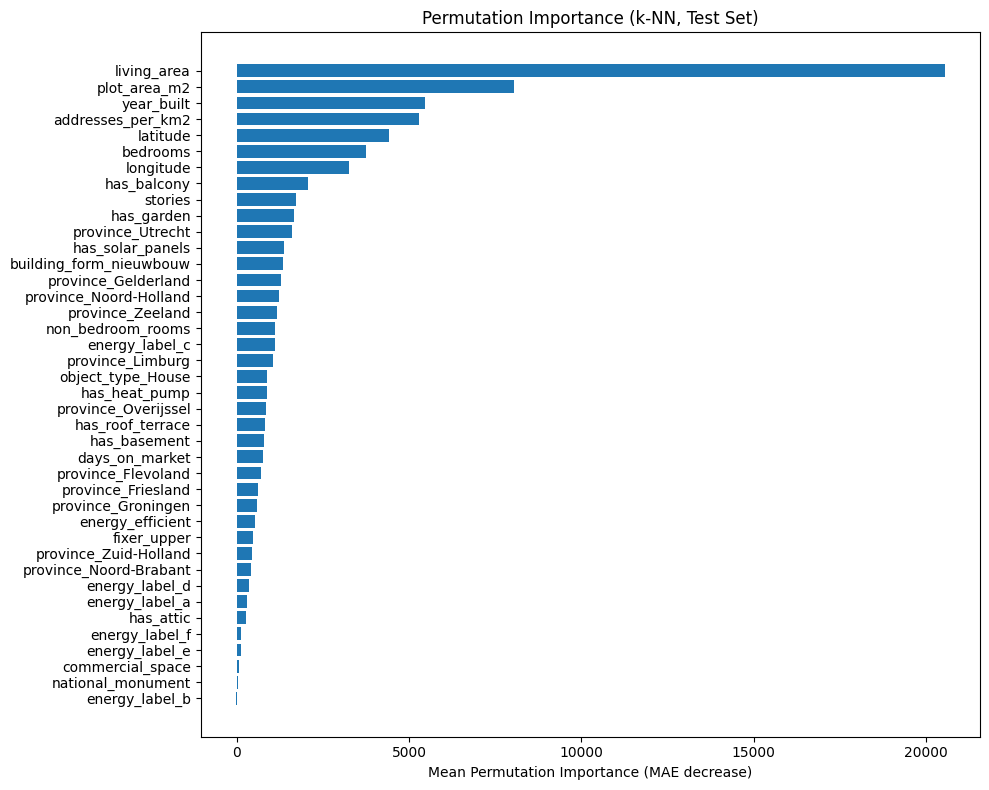

In [12]:
from sklearn.inspection import permutation_importance

import matplotlib.pyplot as plt

# Compute permutation importance on the held-out test set
result = permutation_importance(
    knn, X_test, y_test, n_repeats=10, random_state=42, scoring='neg_mean_absolute_error', n_jobs=-1
)

# Get mean importances and sort
importances = result.importances_mean
indices = np.argsort(importances)[::-1]
feature_names = X_test.columns

# Plot
plt.figure(figsize=(10, 8))
plt.barh(range(len(indices)), importances[indices], align='center')
plt.yticks(range(len(indices)), feature_names[indices])
plt.xlabel("Mean Permutation Importance (MAE decrease)")
plt.title("Permutation Importance (k-NN, Test Set)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [13]:
# Print top 10 features and their importance scores in JSON format
# Fix: Print top 10 permutation importances for k-NN in JSON format

import json

# Get top 10 features by permutation importance
top_10_indices = indices
top_10_features = {feature_names[i]: float(importances[i]) for i in top_10_indices}

print("\nTop 10 Features and Permutation Importances (JSON):")
print(json.dumps(top_10_features, indent=4))


Top 10 Features and Permutation Importances (JSON):
{
    "living_area": 20533.09793248795,
    "plot_area_m2": 8056.269570138975,
    "year_built": 5476.100350596417,
    "addresses_per_km2": 5298.863747337642,
    "latitude": 4414.732281625371,
    "bedrooms": 3744.8585344206344,
    "longitude": 3270.646089270391,
    "has_balcony": 2076.5742685412297,
    "stories": 1714.4827430859143,
    "has_garden": 1676.6807675015552,
    "province_Utrecht": 1606.64705152616,
    "has_solar_panels": 1375.0771673936506,
    "building_form_nieuwbouw": 1337.1756644336833,
    "province_Gelderland": 1279.504400270866,
    "province_Noord-Holland": 1232.8196747083143,
    "province_Zeeland": 1161.6243328984776,
    "non_bedroom_rooms": 1110.0060412667146,
    "energy_label_c": 1107.2074021524436,
    "province_Limburg": 1050.9444955318183,
    "object_type_House": 893.0030237076702,
    "has_heat_pump": 877.2384699697126,
    "province_Overijssel": 841.1727459373142,
    "has_roof_terrace": 834.66

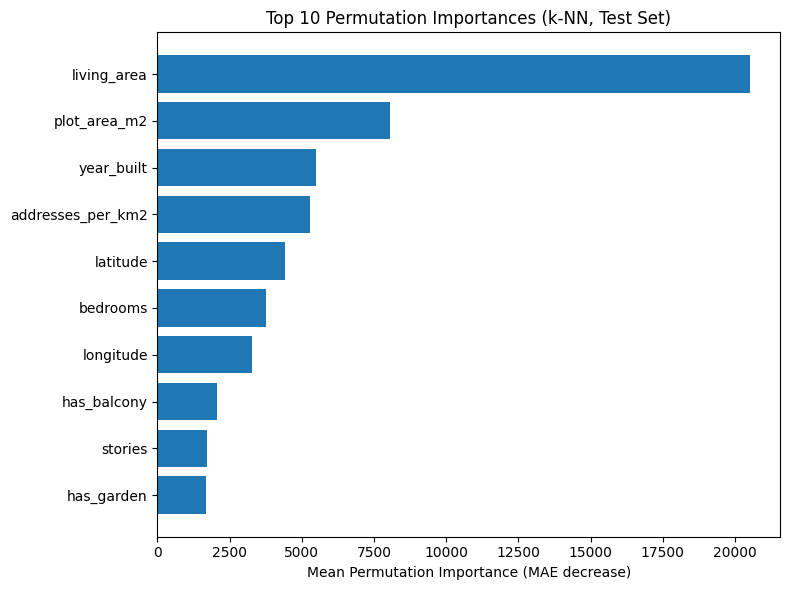

In [14]:
top_n = 10
top_indices = indices[:top_n]

plt.figure(figsize=(8, 6))
plt.barh(range(top_n), importances[top_indices], align='center')
plt.yticks(range(top_n), feature_names[top_indices])
plt.xlabel("Mean Permutation Importance (MAE decrease)")
plt.title("Top 10 Permutation Importances (k-NN, Test Set)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

/var/folders/dm/_tq0dqfd50b73lqr6vh5dcwh0000gn/T/ipykernel_7024/3403556319.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_xticklabels(plt.gca().get_xticklabels(), fontsize=10)


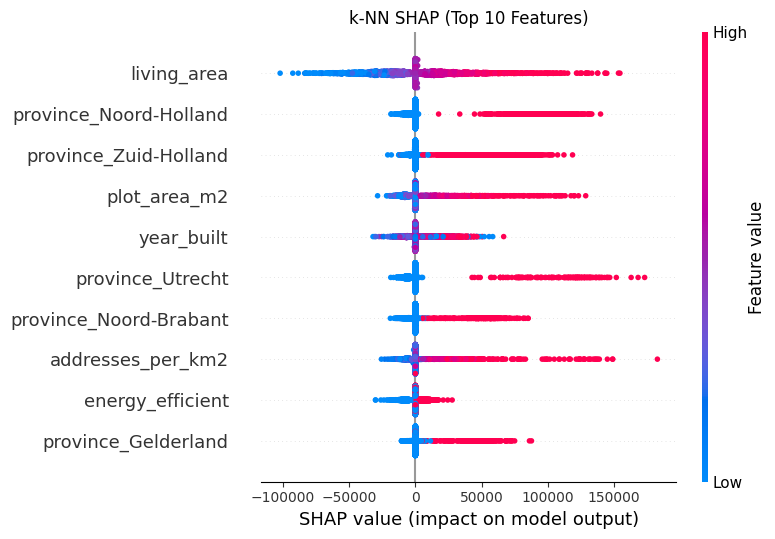

In [12]:
#save plot
shap.summary_plot(shap_vals[:, top10], X_eval.iloc[:, top10], plot_type="dot", show=False)
plt.title("k-NN SHAP (Top 10 Features)")
plt.tight_layout()
plt.gca().set_xticklabels(plt.gca().get_xticklabels(), fontsize=10)
plt.savefig('./plots/knn_shap_10.png', dpi=300, bbox_inches='tight')
plt.show()
